In [151]:
import pandas as pd
import plotly.express as px

In [152]:
df_insertion = pd.read_csv('insertion.csv')
df_mergeSort = pd.read_csv('mergeSort.csv')
df_quickSort = pd.read_csv('quickSort.csv')

In [153]:
df_insertion_media = df_insertion.groupby('Quantidade', as_index=False)['Tempo(segundos)'].mean()

In [154]:
df_insertion_media

,Quantidade,Tempo(segundos)
0,1000,0.00023
1,5000,0.00832
2,10000,0.03321
3,50000,0.83660
4,100000,3.38098


In [155]:
grafico_insertion_barra = px.bar(df_insertion_media,
                           x=df_insertion_media['Quantidade'].astype(str),
                           y='Tempo(segundos)',
                           title='Instância x Tempo(s) médio - Insertion',
                           labels={'Quantidade': 'Instância', 'Tempo(segundos)': 'Tempo(s)'})

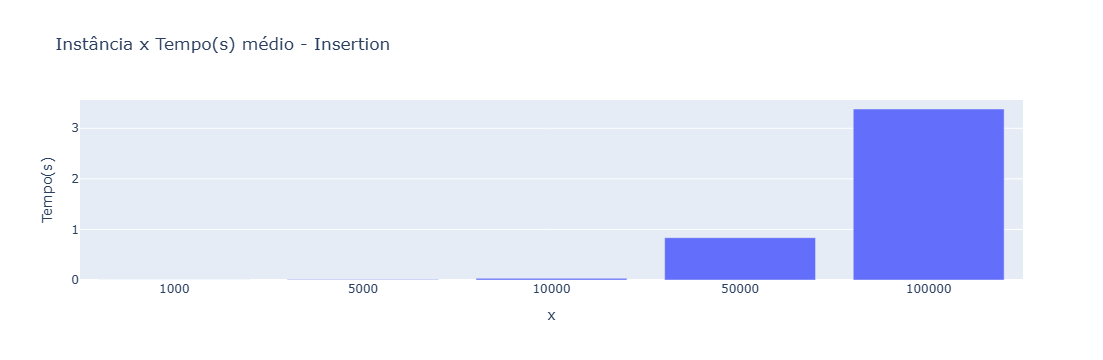

In [156]:
grafico_insertion_barra.show()

In [157]:
grafico_insertion_linha = px.line(df_insertion_media,
                           x=df_insertion_media['Quantidade'].astype(str),
                           y='Tempo(segundos)',
                           markers=True,
                           title='Instância x Tempo(s) médio - Insertion',
                           labels={'Quantidade': 'Instância', 'Tempo(segundos)': 'Tempo(s)'})

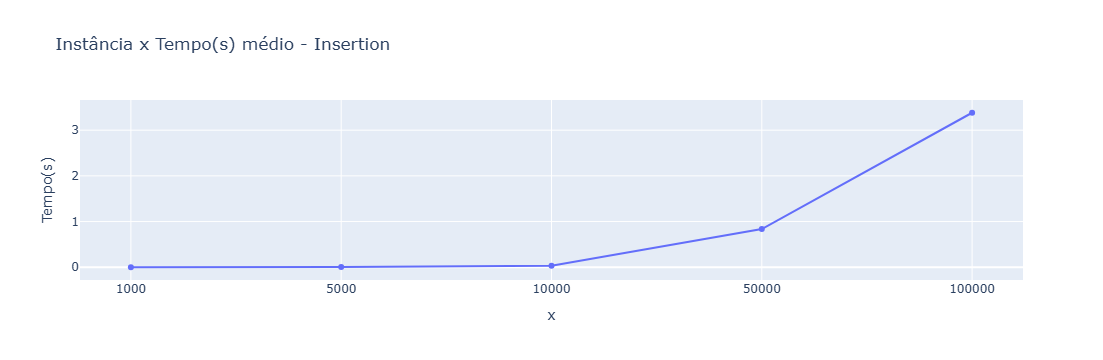

In [158]:
grafico_insertion_linha.show()

➡️ **Análise:**

* O tempo cresce de forma **quadrática**, ou seja, cada vez que o tamanho do vetor aumenta, o tempo cresce de forma muito mais acentuada.
* Exemplo: de 10.000 para 100.000 (aumenta 10x em tamanho) → o tempo cresce de 0.03s para 3.38s (≈100x mais lento).
* Isso mostra claramente o **comportamento O(n²)** — o custo cresce rapidamente com entradas grandes.
* Ideal apenas para **vetores pequenos** (abaixo de 5.000 elementos).

In [159]:
df_mergeSort_media = df_mergeSort.groupby('Quantidade', as_index=False)['Tempo(segundos)'].mean()

In [160]:
df_mergeSort_media

,Quantidade,Tempo(segundos)
0,1000,0.00015
1,5000,0.00143
2,10000,0.00273
3,50000,0.01467
4,100000,0.02891
5,500000,0.14717
6,1000000,0.29730


In [161]:
grafico_mergeSort_barra = px.bar(df_mergeSort_media,
                           x=df_mergeSort_media['Quantidade'].astype(str),
                           y='Tempo(segundos)',
                           title='Instância x Tempo(s) médio - MergeSort',
                           labels={'Quantidade': 'Instância', 'Tempo(segundos)': 'Tempo(s)'})

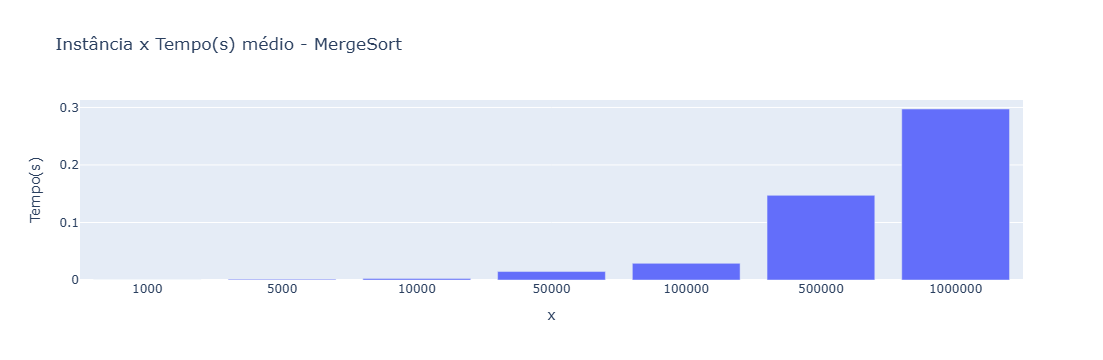

In [162]:
grafico_mergeSort_barra.show()

In [163]:
grafico_mergeSort_linha = px.line(df_mergeSort_media,
                           x=df_mergeSort_media['Quantidade'].astype(str),
                           y='Tempo(segundos)',
                           markers=True,
                           title='Instância x Tempo(s) médio - MergeSort',
                           labels={'Quantidade': 'Instância', 'Tempo(segundos)': 'Tempo(s)'})

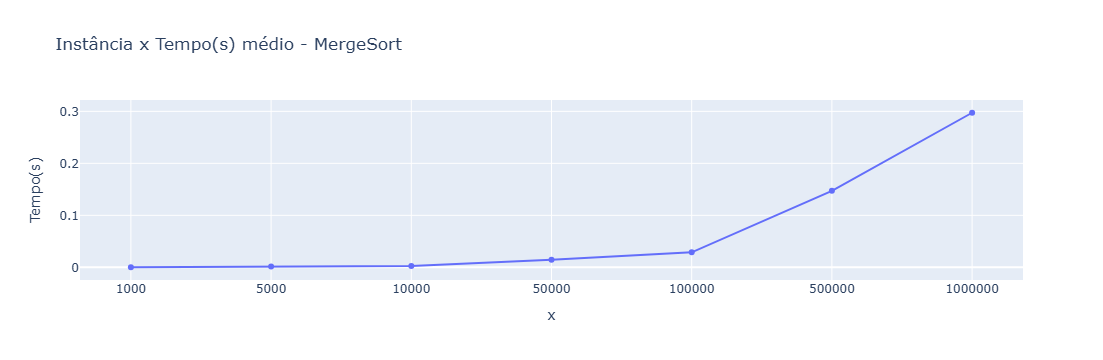

In [164]:
grafico_mergeSort_linha.show()

➡️ **Análise:**

* O crescimento do tempo é **quase linear-logarítmico**, muito estável.
* Ao multiplicar o tamanho por 10, o tempo aumenta apenas ~10x — coerente com a **complexidade O(n log n)**.
* O comportamento é **bastante previsível** e sem variações bruscas.
* O MergeSort é **estável** (mantém ordem relativa de elementos iguais) e **muito eficiente para grandes volumes de dados**.


In [165]:
df_quickSort_media = df_quickSort.groupby('Quantidade', as_index=False)['Tempo(segundos)'].mean()

In [166]:
df_quickSort_media

,Quantidade,Tempo(segundos)
0,1000,0.00015
1,5000,0.00016
2,10000,0.00063
3,50000,0.00328
4,100000,0.00671
5,500000,0.03972
6,1000000,0.09538


In [167]:
grafico_quickSort_barra = px.bar(df_quickSort_media,
                           x=df_quickSort_media['Quantidade'].astype(str),
                           y='Tempo(segundos)',
                           title='Instância x Tempo(s) médio - QuickSort',
                           labels={'Quantidade': 'Instância', 'Tempo(segundos)': 'Tempo(s)'})

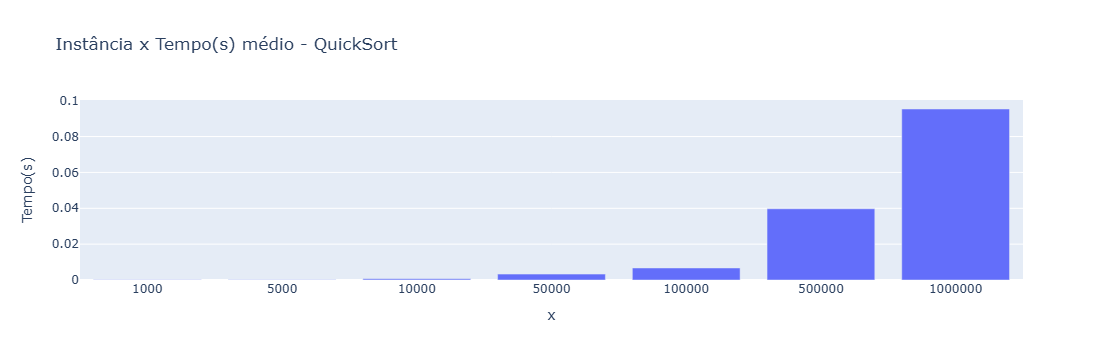

In [168]:
grafico_quickSort_barra.show()

In [169]:
grafico_quickSort_linha = px.line(df_quickSort_media,
                           x=df_quickSort_media['Quantidade'].astype(str),
                           y='Tempo(segundos)',
                           markers=True,
                           title='Instância x Tempo(s) médio - QuickSort',
                           labels={'Quantidade': 'Instância', 'Tempo(segundos)': 'Tempo(s)'})

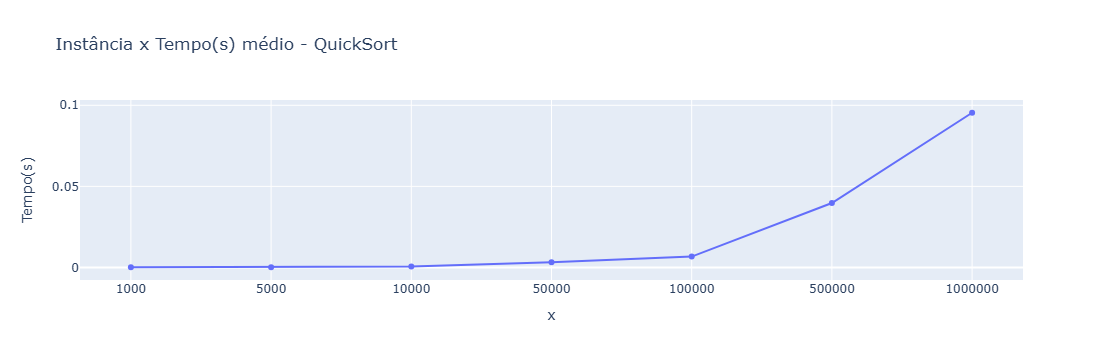

In [170]:
grafico_quickSort_linha.show()

➡️ **Análise:**

* É o algoritmo **mais rápido em praticamente todos os tamanhos de entrada**.
* Mantém um crescimento **próximo de O(n log n)**, mas com **melhor constante de execução** que o MergeSort, pois:

  * Usa menos memória (ordenação in-place);
  * Tem boa localidade de referência (melhor uso de cache);
  * A implementação prática é mais otimizada.
* Não há indício de pior caso (O(n²)) nos testes, o que é esperado, já que os vetores foram aleatórios — isso evita partições desbalanceadas.

In [171]:
df_insertion_media['Algoritmo'] = 'Insertion'
df_mergeSort_media['Algoritmo'] = 'MergeSort'
df_quickSort_media['Algoritmo'] = 'QuickSort'

In [172]:
df_comparativo = pd.concat([df_insertion_media, df_mergeSort_media, df_quickSort_media])

In [173]:
df_comparativo = df_comparativo.sort_values(by='Quantidade')

In [174]:
df_comparativo

,Quantidade,Tempo(segundos),Algoritmo
0,1000,0.00023,Insertion
0,1000,0.00015,MergeSort
0,1000,0.00015,QuickSort
1,5000,0.00832,Insertion
1,5000,0.00143,MergeSort
1,5000,0.00016,QuickSort
2,10000,0.03321,Insertion
2,10000,0.00273,MergeSort
2,10000,0.00063,QuickSort
3,50000,0.83660,Insertion


In [175]:
grafico_comparativo = px.line(df_comparativo,
                              x=df_comparativo['Quantidade'].astype(str),
                              y='Tempo(segundos)',
                              color='Algoritmo',
                              markers=True,
                              title='Comparativo entre: Insertion x MergeSort x QuickSort')

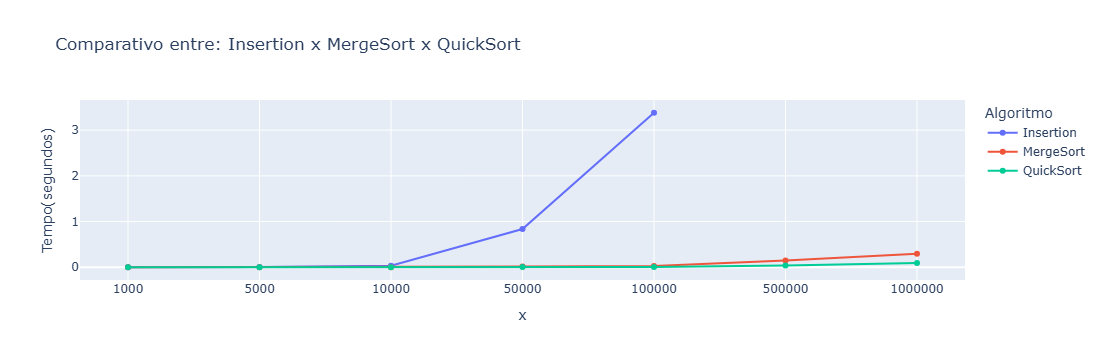

In [176]:
grafico_comparativo.show()

➡️ **Conclusões gerais:**

* **QuickSort** é o **mais rápido** em todos os cenários experimentais.
* **MergeSort** é **ligeiramente mais lento**, mas **mais estável** (não depende da distribuição dos dados).
* **Insertion Sort** só é competitivo em **pequenas instâncias** — depois disso, o crescimento é explosivo.

In [177]:
df_insertion['Algoritmo'] = 'Insertion'
df_mergeSort['Algoritmo'] = 'MergeSort'
df_quickSort['Algoritmo'] = 'QuickSort'

In [178]:
df_comparativo_cru = pd.concat([df_insertion, df_mergeSort, df_quickSort])

In [179]:
grafico_comparativo_boxplot = px.box(df_comparativo_cru,
                                     x=df_comparativo_cru['Quantidade'].astype(str),
                                     y='Tempo(segundos)',
                                     color='Algoritmo',
                                     points='outliers',
                                     title='Distribuição dos tempos de execução - Insertion x MergeSort x QuickSort')

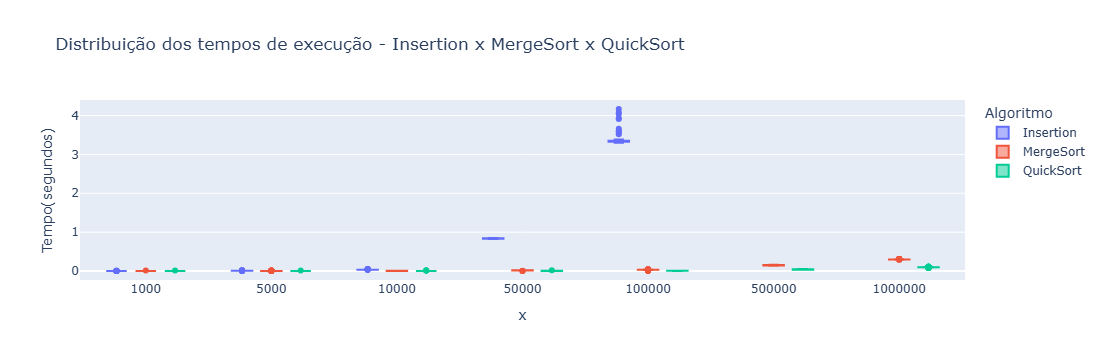

In [180]:
grafico_comparativo_boxplot.show()

➡️ **Conclusões gerais:**

O gráfico boxplot mostra a **distribuição dos tempos de execução** de cada algoritmo para um mesmo tamanho de vetor, permitindo observar a **variação (dispersão)** e **presença de outliers(valores fora do padrão)**.

🔹 **Sobre o Insertion Sort:**

O **Insertion Sort** apresenta **maior dispersão** nos tempos de execução para instâncias grandes (como vetores de 100.000 elementos). Isso significa que, quando o tamanho do vetor cresce, **os tempos medidos variam mais entre uma execução e outra**, indicando que o algoritmo é **mais sensível às variações da entrada** — por exemplo, diferentes distribuições de números aleatórios podem impactar fortemente seu desempenho.

Em contrapartida, **Merge Sort** e **Quick Sort** mantêm **dispersões menores**, ou seja, seus tempos de execução ficam **mais consistentes** mesmo para instâncias grandes, refletindo o comportamento **mais previsível e estável** de algoritmos com complexidade média O(n log n).